Importing libraries 


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

In [84]:
df =  pd.read_csv("Dataset_1.csv")

In [85]:
df.head()

,accident_id,accident_datetime,state,district,area_type,latitude,longitude,road_type,road_condition,road_lighting,...,ambulance_called,police_called,response_time_minutes,hospitalization_required,num_vehicles,num_injuries,num_fatalities,accident_severity,insurance_claim_filed,insurance_claim_amount
0,ACC20240000709,2024-12-15 15:14:47,Karnataka,Hubli District,Rural,15.741067,74.555047,State Highway,Pothole-Ridden,Streetlight Absent,...,No,Yes,86.178166,Yes,2,3,1,Severe,No,NaN
1,ACC20200196249,2020-09-09 21:36:54,Haryana,Faridabad District,Urban,30.211127,75.461897,Other District Road,Dry,Streetlight Absent,...,No,No,NaN,No,2,0,0,Minor,Yes,26761.0
2,ACC20180059148,2018-07-24 16:43:57,West Bengal,Siliguri District,Semi-Urban,23.782972,86.281103,State Highway,Under Construction,Streetlight Absent,...,No,No,NaN,No,5,2,0,Moderate,Yes,9295.0
3,ACC20160076737,2016-11-17 17:53:16,West Bengal,Howrah District,Rural,24.872909,87.339504,National Highway,Dry,Streetlight Absent,...,Yes,Yes,16.943981,No,1,0,0,Minor,Yes,48147.0
4,ACC20230004919,2023-03-18 23:35:24,Rajasthan,Jodhpur District,Semi-Urban,24.305082,74.252979,State Highway,Dry,Streetlight Present,...,No,No,NaN,No,3,0,0,Minor,Yes,20636.0


In [86]:
df.shape

(202000, 48)

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 202000 entries, 0 to 201999
Data columns (total 48 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   accident_id                202000 non-null  str    
 1   accident_datetime          202000 non-null  str    
 2   state                      202000 non-null  str    
 3   district                   195938 non-null  str    
 4   area_type                  202000 non-null  str    
 5   latitude                   192022 non-null  float64
 6   longitude                  192022 non-null  float64
 7   road_type                  202000 non-null  str    
 8   road_condition             202000 non-null  str    
 9   road_lighting              195936 non-null  str    
 10  number_of_lanes            193914 non-null  float64
 11  speed_limit_kmph           191888 non-null  float64
 12  estimated_speed_kmph       202000 non-null  float64
 13  junction_type              195935 non-nu

In [88]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,192022.0,21.762030,8.743458,-89.993206,17.832292,23.361621,26.645448,89.967149
longitude,192022.0,77.979976,15.193053,-179.316379,75.580903,77.912843,82.083551,179.807326
number_of_lanes,193914.0,2.847850,1.421580,1.000000,2.000000,2.000000,4.000000,6.000000
speed_limit_kmph,191888.0,58.830516,23.129471,20.000000,40.000000,60.000000,70.000000,120.000000
estimated_speed_kmph,202000.0,61.670709,29.602714,5.000000,39.900000,57.300000,78.200000,160.000000
visibility_km,189879.0,4.912759,2.851291,0.020000,2.660000,4.710000,7.360000,10.850000
temperature_c,191903.0,22.199841,8.149343,2.000000,15.600000,22.300000,28.800000,47.000000
rainfall_mm,202000.0,3.488586,10.438514,0.000000,0.000000,0.000000,0.000000,252.100000
driver_age,173756.0,36.482193,12.820925,13.000000,27.000000,36.000000,45.000000,102.000000
driving_experience_years,173756.0,16.723268,11.906786,0.000000,7.100000,16.000000,24.900000,55.000000


In [89]:
df.describe(include='object')

C:\Users\pushk\AppData\Local\Temp\ipykernel_11676\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,accident_id,accident_datetime,state,district,area_type,road_type,road_condition,road_lighting,junction_type,traffic_signal_present,...,vehicle_condition,overloading_status,primary_cause,secondary_cause,emergency_services_called,ambulance_called,police_called,hospitalization_required,accident_severity,insurance_claim_filed
count,202000,202000,202000,195938,202000,202000,202000,195936,195935,193937,...,202000,191891,202000,62925,202000,202000,202000,193928,202000,202000
unique,200000,199922,21,87,3,20,5,2,6,8,...,4,4,13,13,2,2,2,2,4,3
top,ACC20150003462,2015-10-20 10:01:09,Uttar Pradesh,Kanpur District,Urban,Other District Road,Dry,Streetlight Present,No Junction,No,...,Good,Not Applicable,Weather,Overspeeding,No,No,No,No,Minor,Yes
freq,3,3,28779,4728,91077,54235,125097,117476,68499,119324,...,89115,157225,26415,9761,105773,140345,120266,138207,111094,95781


In [90]:
num_cols = df.describe().columns
non_num_cols = df.drop(num_cols,axis=1).columns
len(num_cols),len(non_num_cols)

(16, 32)

In [91]:
print(num_cols)
print(non_num_cols)

Index(['latitude', 'longitude', 'number_of_lanes', 'speed_limit_kmph',
       'estimated_speed_kmph', 'visibility_km', 'temperature_c', 'rainfall_mm',
       'driver_age', 'driving_experience_years', 'vehicle_age_years',
       'response_time_minutes', 'num_vehicles', 'num_injuries',
       'num_fatalities', 'insurance_claim_amount'],
      dtype='str')
Index(['accident_id', 'accident_datetime', 'state', 'district', 'area_type',
       'road_type', 'road_condition', 'road_lighting', 'junction_type',
       'traffic_signal_present', 'median_present', 'weather_condition',
       'driver_gender', 'license_status', 'alcohol_involved',
       'distraction_involved', 'mobile_phone_used', 'fatigue_involved',
       'helmet_seatbelt_used', 'vehicle_type', 'vehicle_brand',
       'vehicle_model', 'vehicle_condition', 'overloading_status',
       'primary_cause', 'secondary_cause', 'emergency_services_called',
       'ambulance_called', 'police_called', 'hospitalization_required',
       'accide

In [92]:
null_col = df.isnull().sum()
null_col

accident_id                       0
accident_datetime                 0
state                             0
district                       6062
area_type                         0
latitude                       9978
longitude                      9978
road_type                         0
road_condition                    0
road_lighting                  6064
number_of_lanes                8086
speed_limit_kmph              10112
estimated_speed_kmph              0
junction_type                  6065
traffic_signal_present         8063
median_present                 8069
weather_condition              4038
visibility_km                 12121
temperature_c                 10097
rainfall_mm                       0
driver_age                    28244
driver_gender                  6058
driving_experience_years      28244
license_status                    0
alcohol_involved                  0
distraction_involved              0
mobile_phone_used                 0
fatigue_involved            

In [93]:
null_percent  = (null_col/len(df))*100
null_percent
# percentage of the null values in each columns 

accident_id                   0.000000
accident_datetime             0.000000
state                         0.000000
district                      3.000990
area_type                     0.000000
latitude                      4.939604
longitude                     4.939604
road_type                     0.000000
road_condition                0.000000
road_lighting                 3.001980
number_of_lanes               4.002970
speed_limit_kmph              5.005941
estimated_speed_kmph          0.000000
junction_type                 3.002475
traffic_signal_present        3.991584
median_present                3.994554
weather_condition             1.999010
visibility_km                 6.000495
temperature_c                 4.998515
rainfall_mm                   0.000000
driver_age                   13.982178
driver_gender                 2.999010
driving_experience_years     13.982178
license_status                0.000000
alcohol_involved              0.000000
distraction_involved     

In [94]:
df_null = pd.DataFrame({"null_percent": null_percent})
df_null =  df_null[df_null["null_percent"]>0]
df_null

,null_percent
district,3.000990
latitude,4.939604
longitude,4.939604
road_lighting,3.001980
number_of_lanes,4.002970
speed_limit_kmph,5.005941
junction_type,3.002475
traffic_signal_present,3.991584
median_present,3.994554
weather_condition,1.999010


These column contains null values with there given respective percentage null values 

In [95]:
df_null['null_percent'].sort_values()

weather_condition            1.999010
driver_gender                2.999010
district                     3.000990
road_lighting                3.001980
junction_type                3.002475
traffic_signal_present       3.991584
median_present               3.994554
hospitalization_required     3.996040
number_of_lanes              4.002970
latitude                     4.939604
longitude                    4.939604
temperature_c                4.998515
overloading_status           5.004455
speed_limit_kmph             5.005941
visibility_km                6.000495
driver_age                  13.982178
driving_experience_years    13.982178
vehicle_age_years           13.982178
vehicle_brand               19.141584
vehicle_model               21.752970
response_time_minutes       52.362871
insurance_claim_amount      54.902970
secondary_cause             68.849010
Name: null_percent, dtype: float64

In [96]:
non_num_cols = df[non_num_cols].drop(["accident_id","accident_datetime"],axis =1).columns
non_num_cols

Index(['state', 'district', 'area_type', 'road_type', 'road_condition',
       'road_lighting', 'junction_type', 'traffic_signal_present',
       'median_present', 'weather_condition', 'driver_gender',
       'license_status', 'alcohol_involved', 'distraction_involved',
       'mobile_phone_used', 'fatigue_involved', 'helmet_seatbelt_used',
       'vehicle_type', 'vehicle_brand', 'vehicle_model', 'vehicle_condition',
       'overloading_status', 'primary_cause', 'secondary_cause',
       'emergency_services_called', 'ambulance_called', 'police_called',
       'hospitalization_required', 'accident_severity',
       'insurance_claim_filed'],
      dtype='str')

In [97]:
for _ in non_num_cols:
    print(df[_].unique())

<ArrowStringArray>
[       'Karnataka',          'Haryana',      'West Bengal',
        'Rajasthan',      'Maharashtra',          'Gujarat',
    'Uttar Pradesh',           'Kerala',     'Chhattisgarh',
            'Assam', 'Himachal Pradesh',   'Andhra Pradesh',
            'Bihar',   'Madhya Pradesh',            'Delhi',
        'Jharkhand',           'Odisha',       'Tamil Nadu',
        'Telangana',           'Punjab',      'Uttarakhand']
Length: 21, dtype: str
<ArrowStringArray>
[             'Hubli District',          'Faridabad District',
           'Siliguri District',             'Howrah District',
            'Jodhpur District',             'Nagpur District',
           'Vadodara District',               'Agra District',
          'Mangaluru District',         'Aurangabad District',
             'Nashik District',                           nan,
            'Kolkata District',           'Varanasi District',
               'Durg District',             'Ambala District',
        

In [98]:
len(non_num_cols)

30

In [99]:
unique_elements = {
    col: df[col].unique() for col in non_num_cols
}

unique_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in unique_elements.items()]))
unique_df.T

,0,1,2,3,4,5,6,7,8,9,...,78,79,80,81,82,83,84,85,86,87
state,Karnataka,Haryana,West Bengal,Rajasthan,Maharashtra,Gujarat,Uttar Pradesh,Kerala,Chhattisgarh,Assam,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,Hubli District,Faridabad District,Siliguri District,Howrah District,Jodhpur District,Nagpur District,Vadodara District,Agra District,Mangaluru District,Aurangabad District,...,Kochi District,Roorkee District,Hyderabad District,Manali District,Bhilai District,Nainital District,Bhubaneswar District,Jamshedpur District,Dehradun District,Solan District
area_type,Rural,Urban,Semi-Urban,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_type,State Highway,Other District Road,National Highway,Village Road,Expressway,state highway,village road,NATIONAL HIGHWAY,National Highway,Other District Road,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_condition,Pothole-Ridden,Dry,Under Construction,Wet,Loose Surface,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_lighting,Streetlight Absent,Streetlight Present,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
junction_type,No Junction,T-Junction,Four Arm Junction,Uncontrolled Junction,NaN,Y-Junction,Roundabout,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_signal_present,Yes,No,NaN,0,N,True,False,Y,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
median_present,Yes,No,NaN,Y,N,False,True,1,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather_condition,Clear,NaN,Rain,Rainy,Hazy,Foggy,Stormy,Foggy,rainy,Rainy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [100]:
for i in  ["road_type","weather_condition","area_type"]:
    print({i:df[i].dropna().unique().tolist()})

{'road_type': ['State Highway', 'Other District Road', 'National Highway', 'Village Road', 'Expressway', 'state highway', 'village road', 'NATIONAL HIGHWAY', ' National Highway ', ' Other District Road ', 'VILLAGE ROAD', 'OTHER DISTRICT ROAD', 'other district road', ' Village Road ', 'national highway', 'EXPRESSWAY', ' State Highway ', ' Expressway ', 'STATE HIGHWAY', 'expressway']}
{'weather_condition': ['Clear', 'Rain', 'Rainy', 'Hazy', 'Foggy', 'Stormy', ' Foggy ', 'rainy', ' Rainy ', ' Clear ', 'clear', 'CLEAR', 'foggy', 'FOGGY', 'hazy', 'RAINY', 'STORMY', 'stormy', ' Stormy ', 'HAZY', ' Hazy ']}
{'area_type': ['Rural', 'Urban', 'Semi-Urban']}


In [101]:
df["road_type"].unique()
# there are 20 different type of roads

<ArrowStringArray>
[        'State Highway',   'Other District Road',      'National Highway',
          'Village Road',            'Expressway',         'state highway',
          'village road',      'NATIONAL HIGHWAY',    ' National Highway ',
 ' Other District Road ',          'VILLAGE ROAD',   'OTHER DISTRICT ROAD',
   'other district road',        ' Village Road ',      'national highway',
            'EXPRESSWAY',       ' State Highway ',          ' Expressway ',
         'STATE HIGHWAY',            'expressway']
Length: 20, dtype: str

<Axes: xlabel='count', ylabel='road_type'>

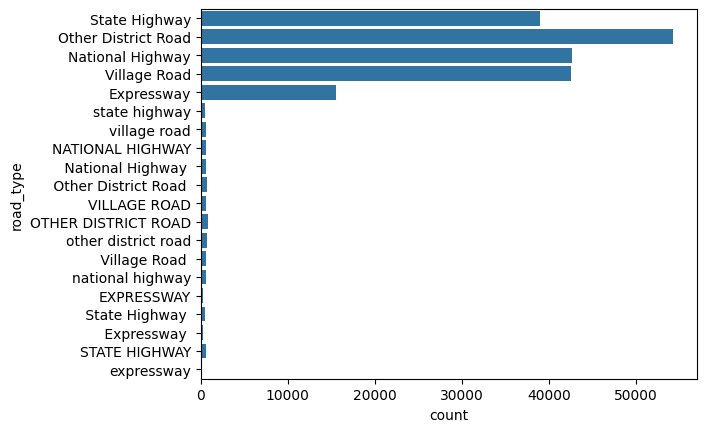

In [102]:
sns.countplot(df["road_type"])

In [103]:
dt = pd.to_datetime(df['accident_datetime'],errors='coerce')
dt

0        2024-12-15 15:14:47
1        2020-09-09 21:36:54
2        2018-07-24 16:43:57
3        2016-11-17 17:53:16
4        2023-03-18 23:35:24
                 ...        
201995   2021-04-01 20:30:23
201996   2025-02-22 19:51:03
201997   2022-09-17 10:30:59
201998   2024-06-23 16:17:20
201999   2019-06-17 13:21:45
Name: accident_datetime, Length: 202000, dtype: datetime64[us]

C:\Users\pushk\AppData\Local\Temp\ipykernel_11676\956257175.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,6))


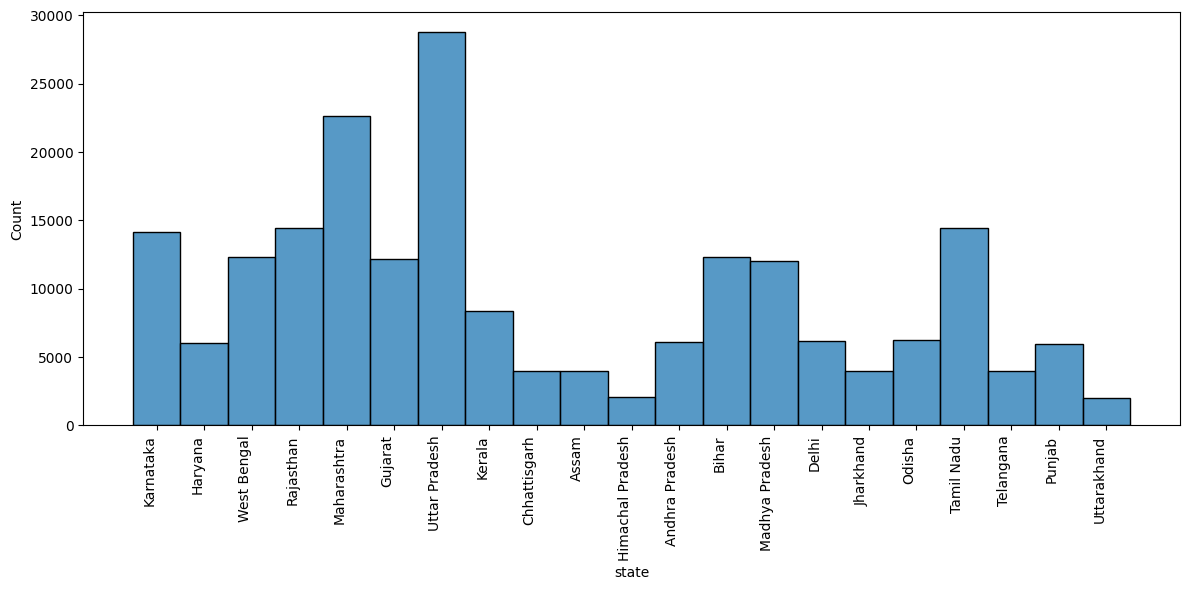

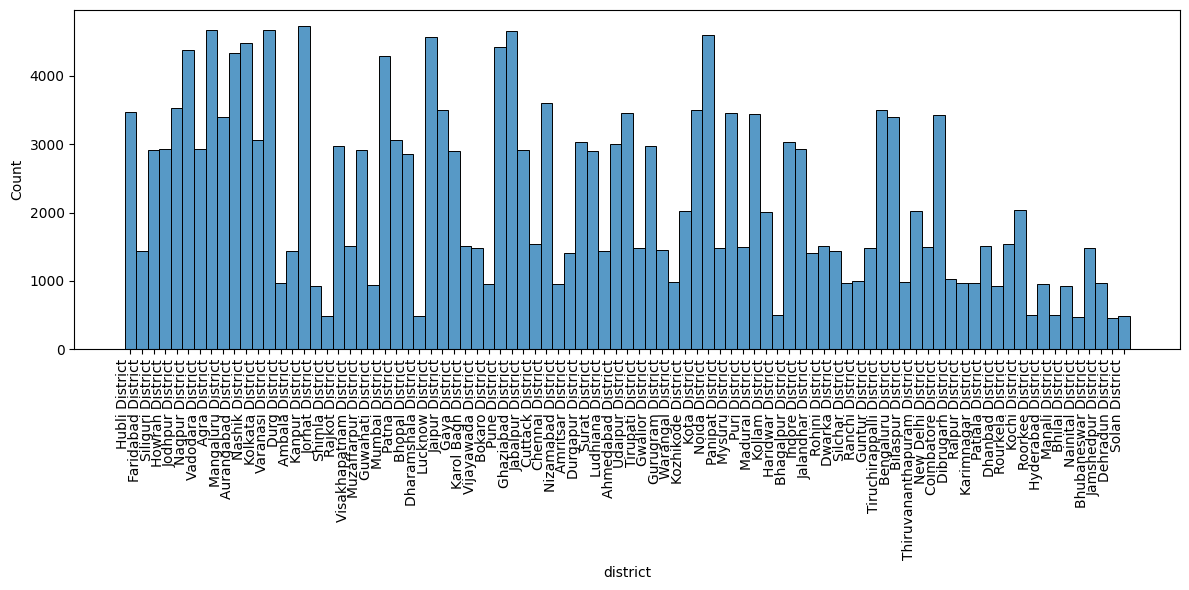

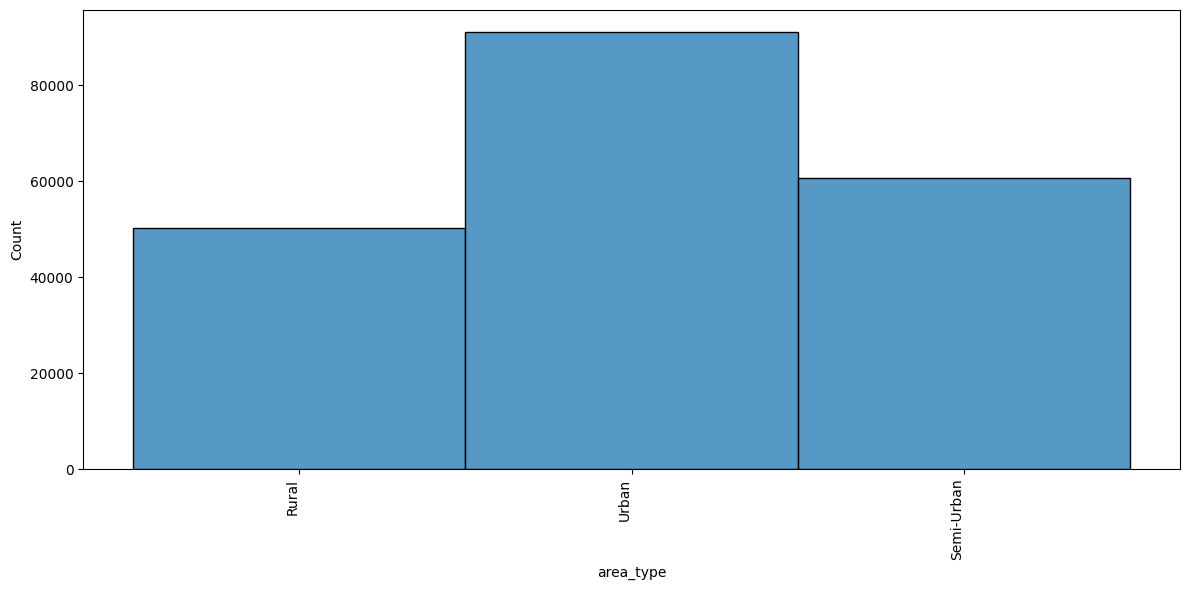

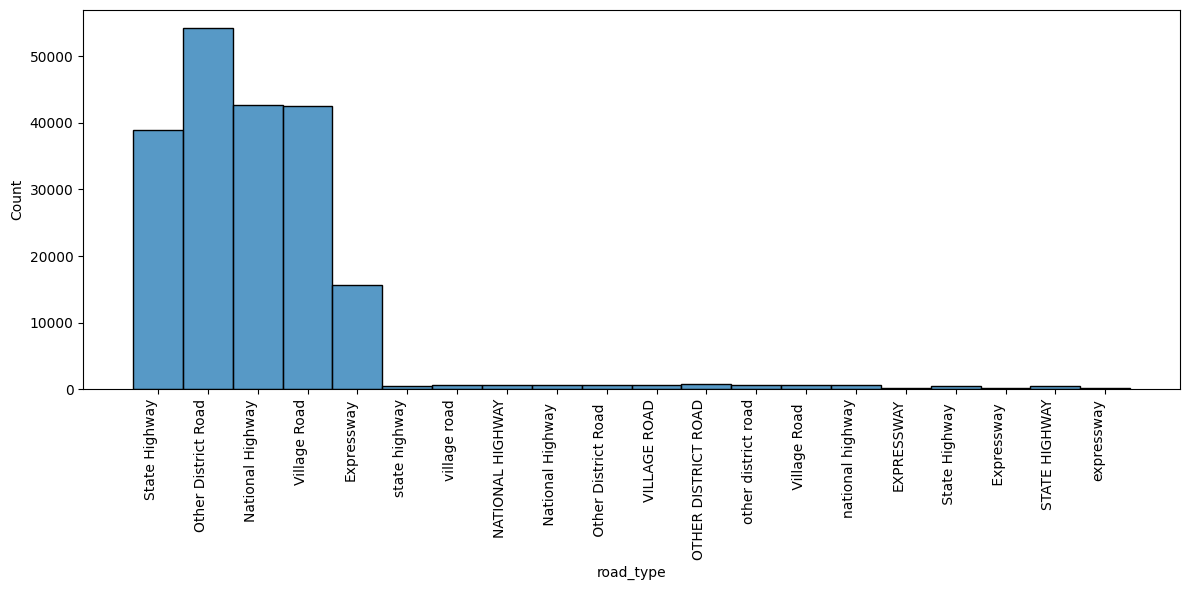

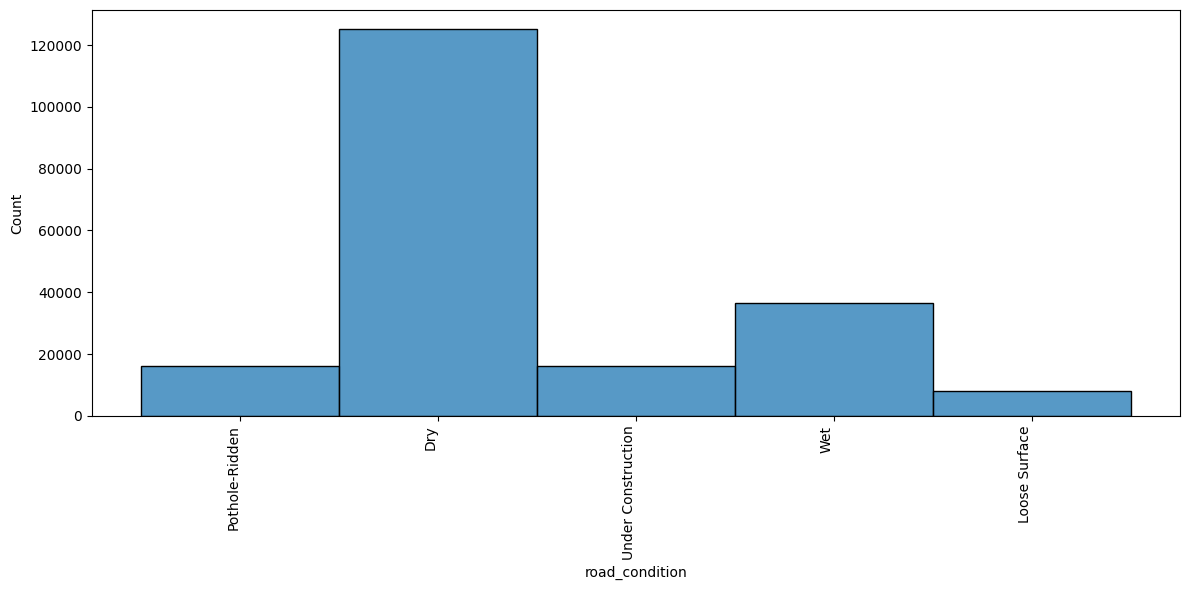

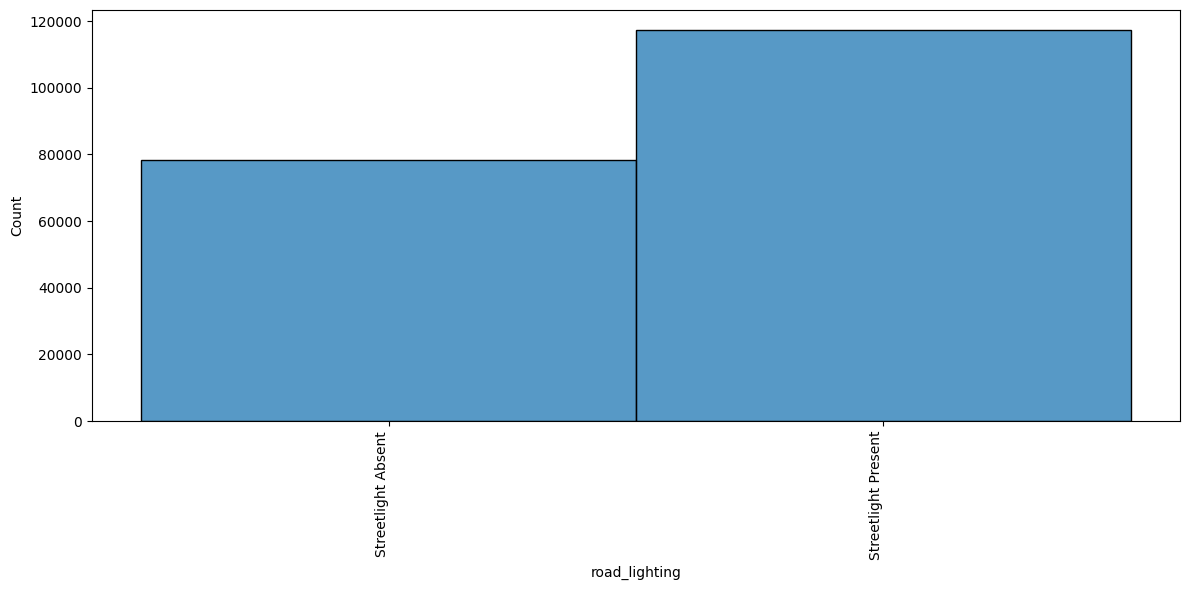

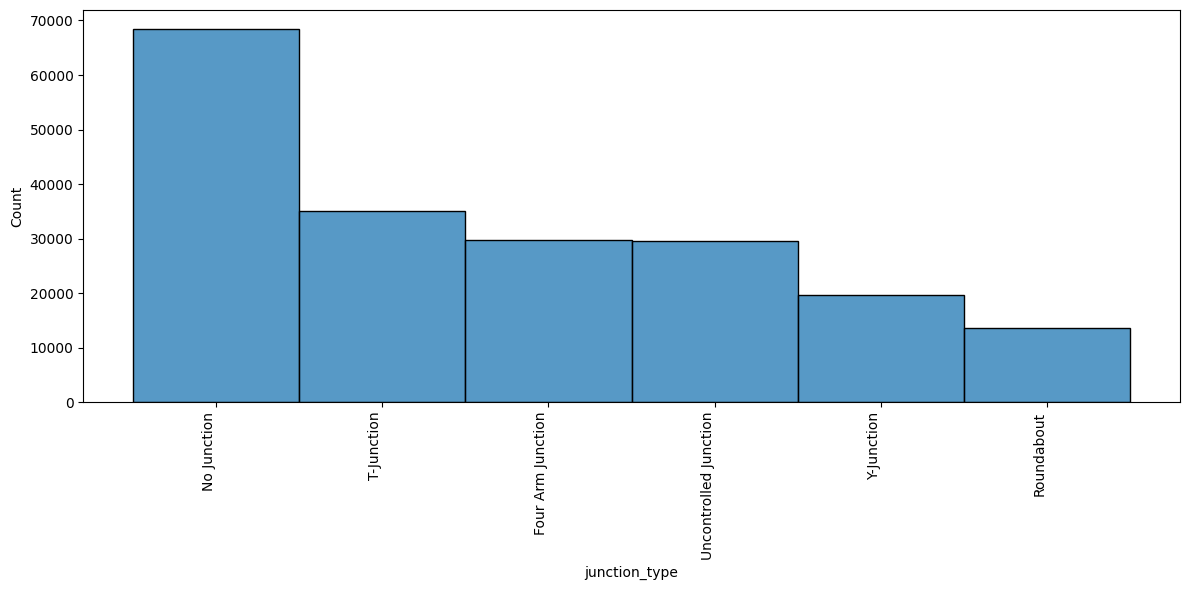

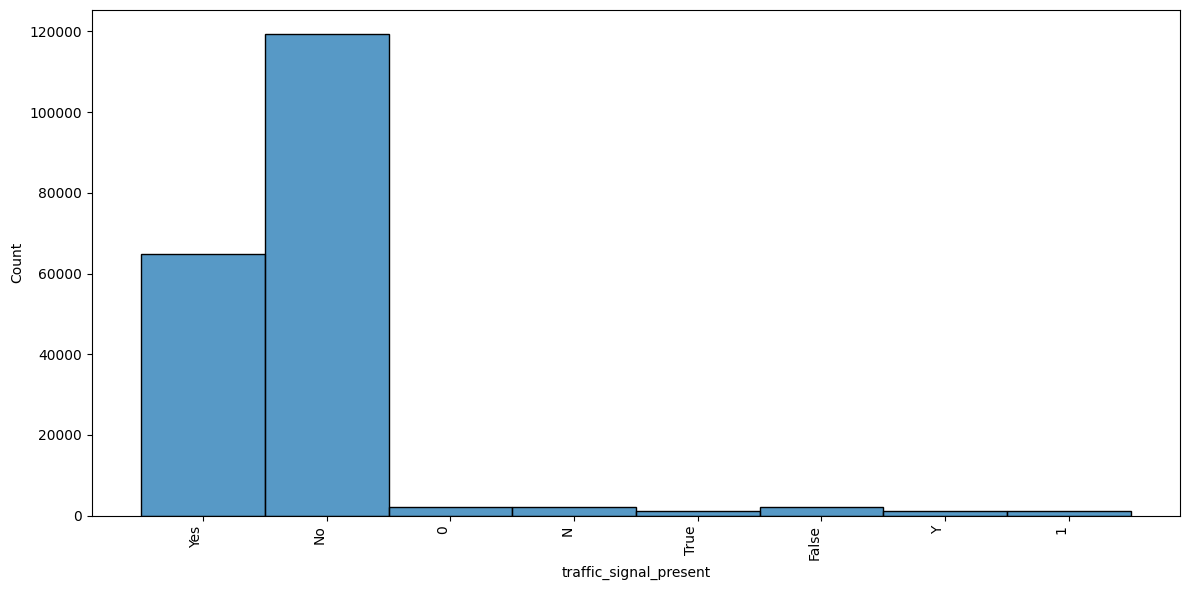

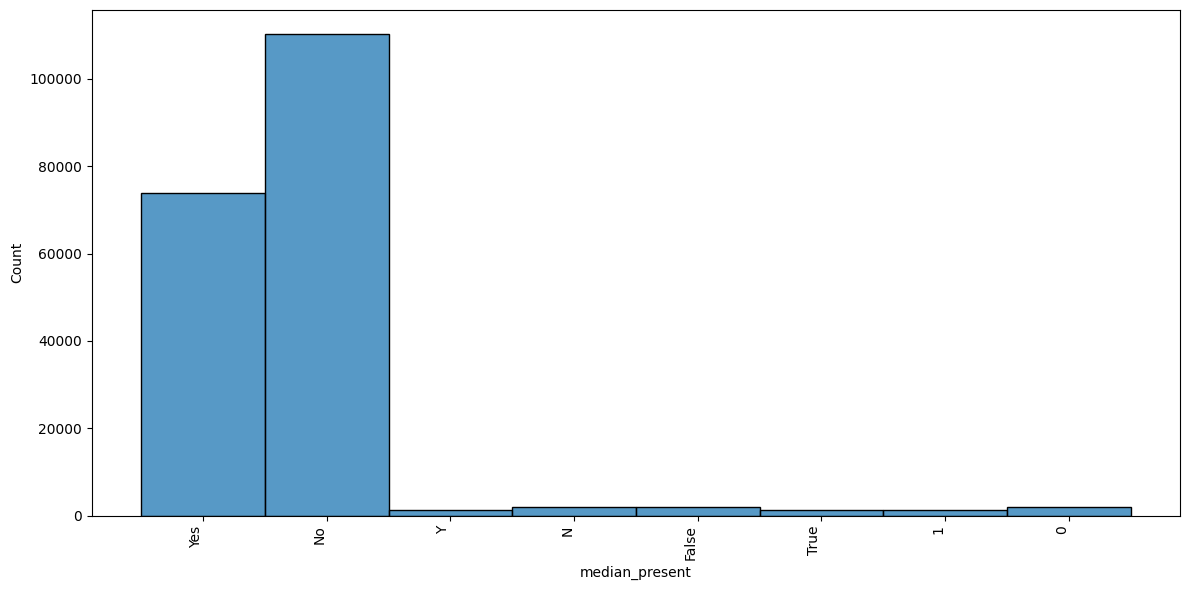

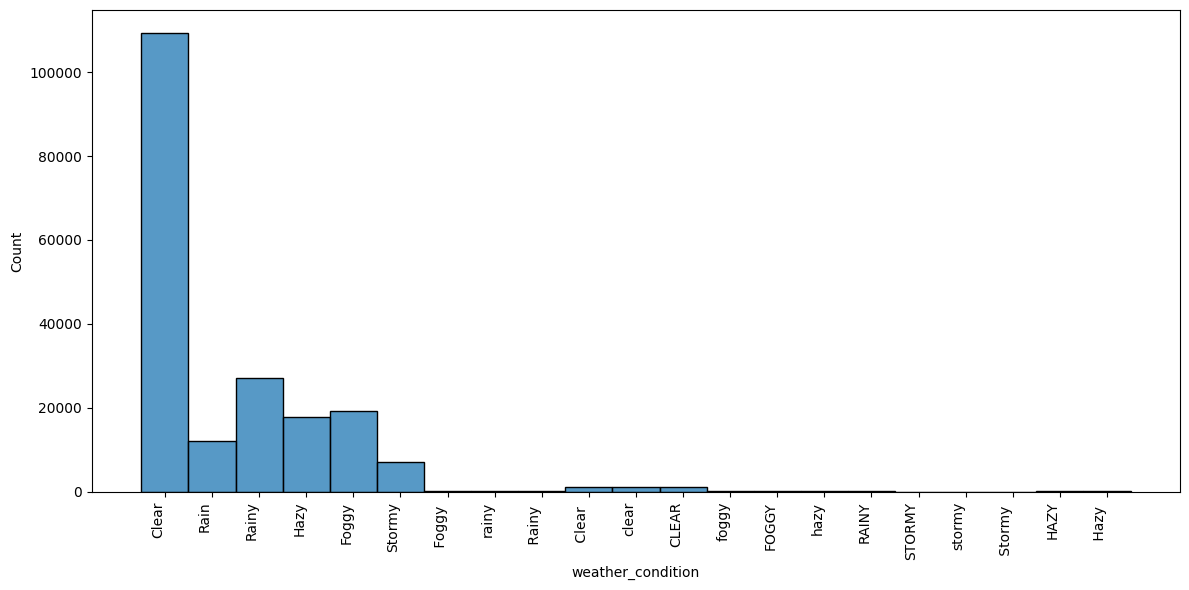

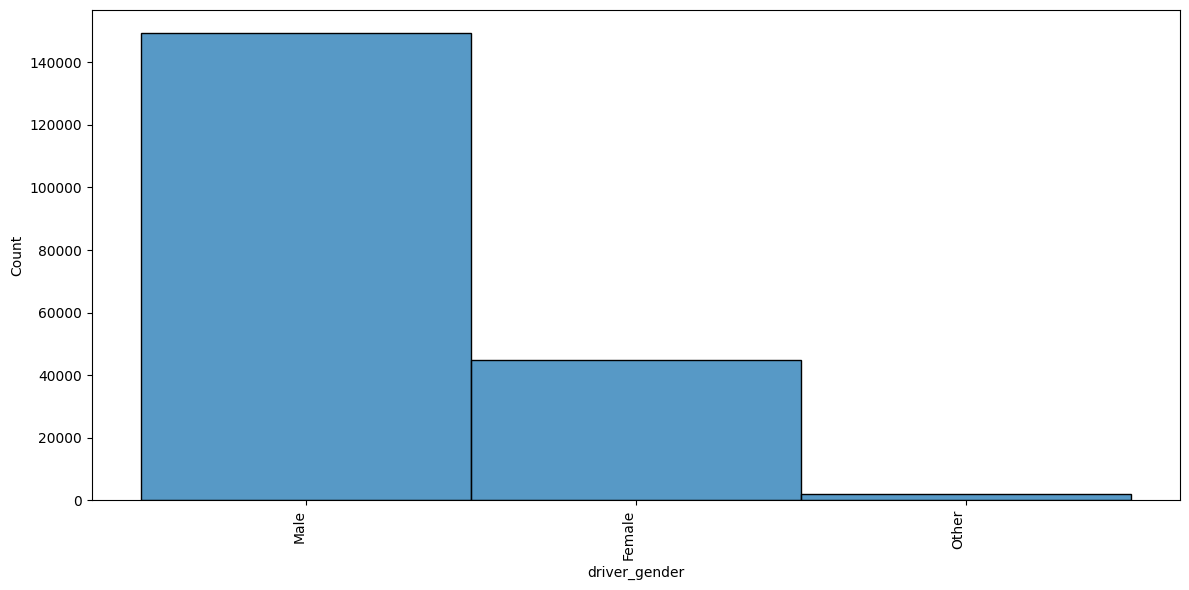

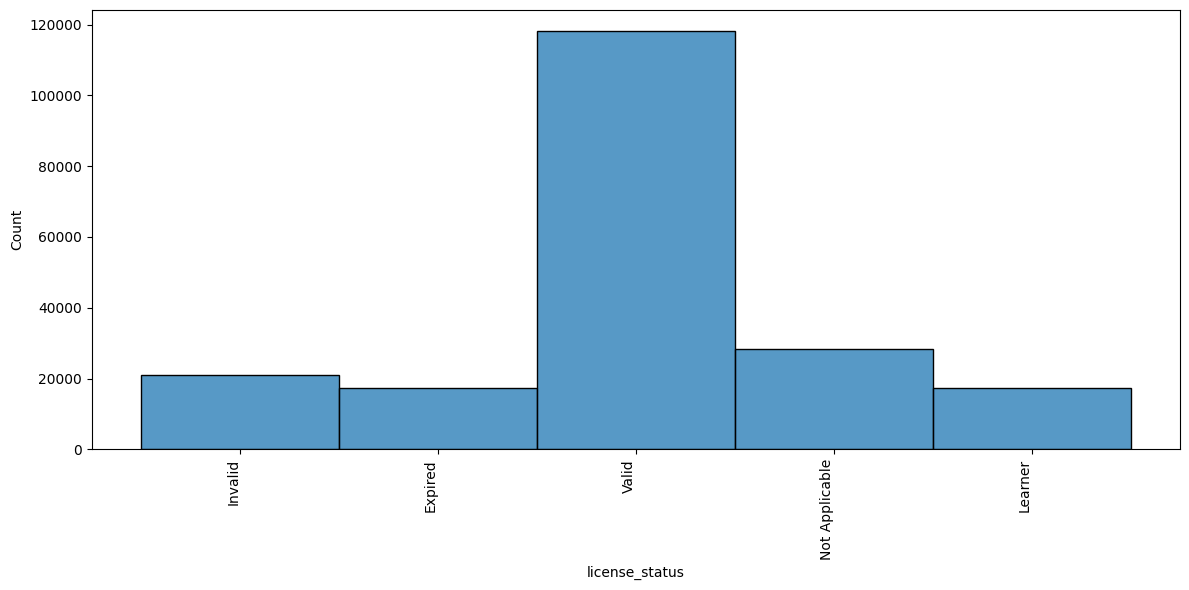

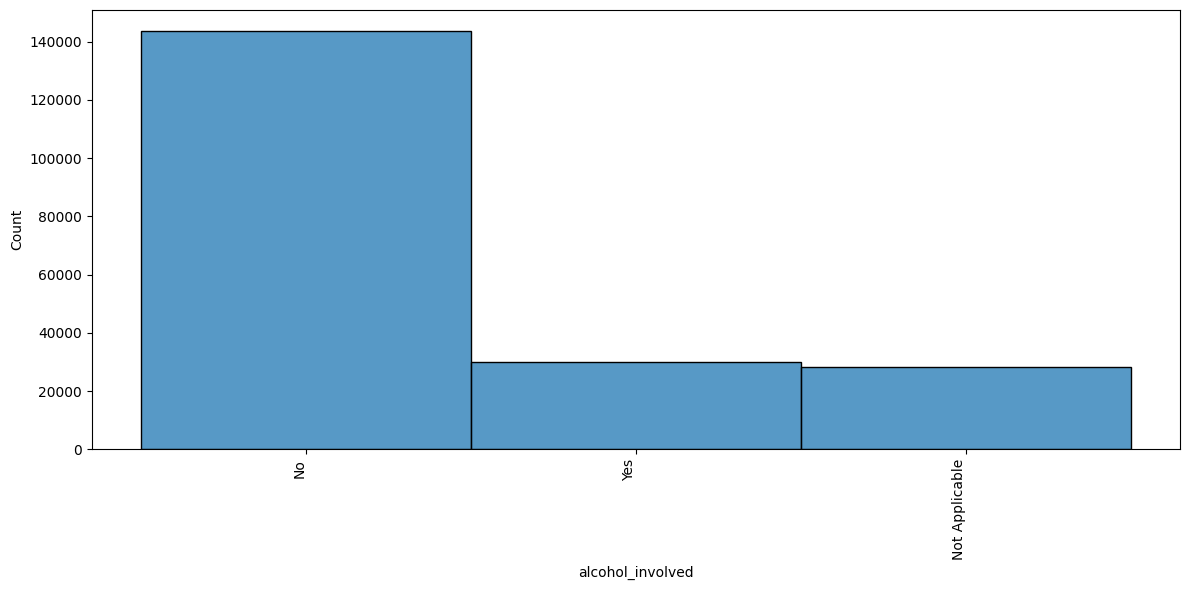

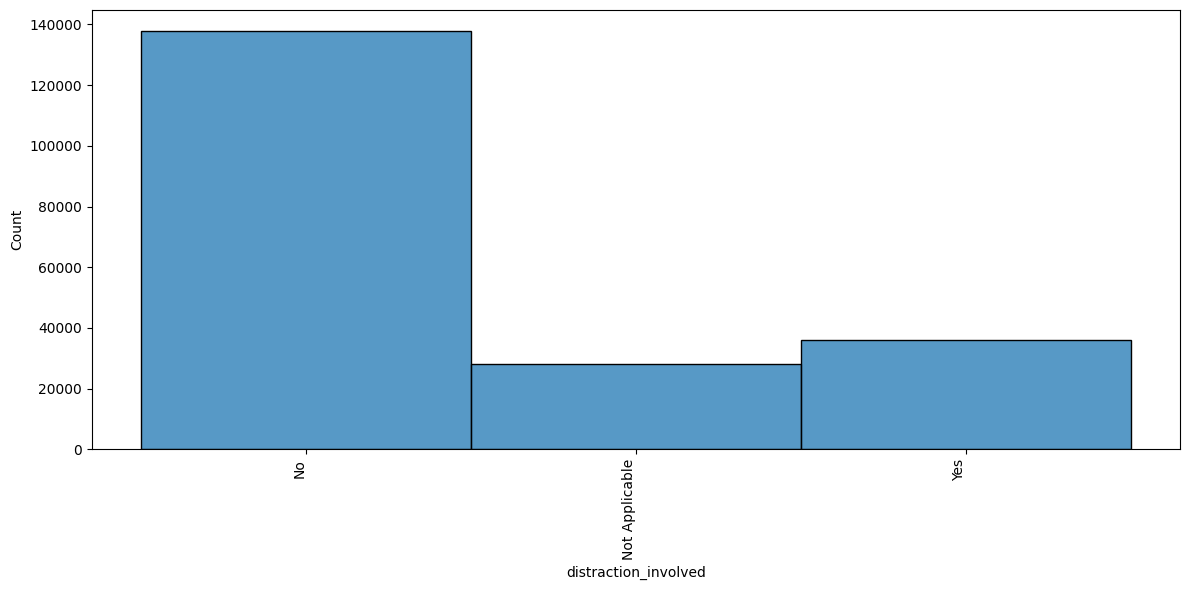

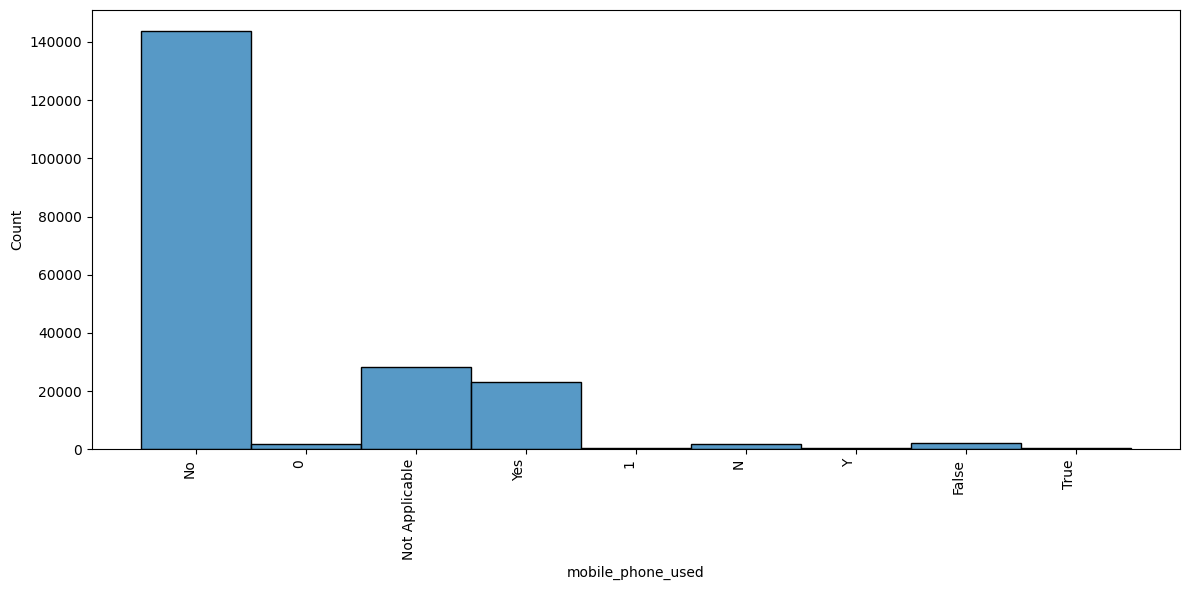

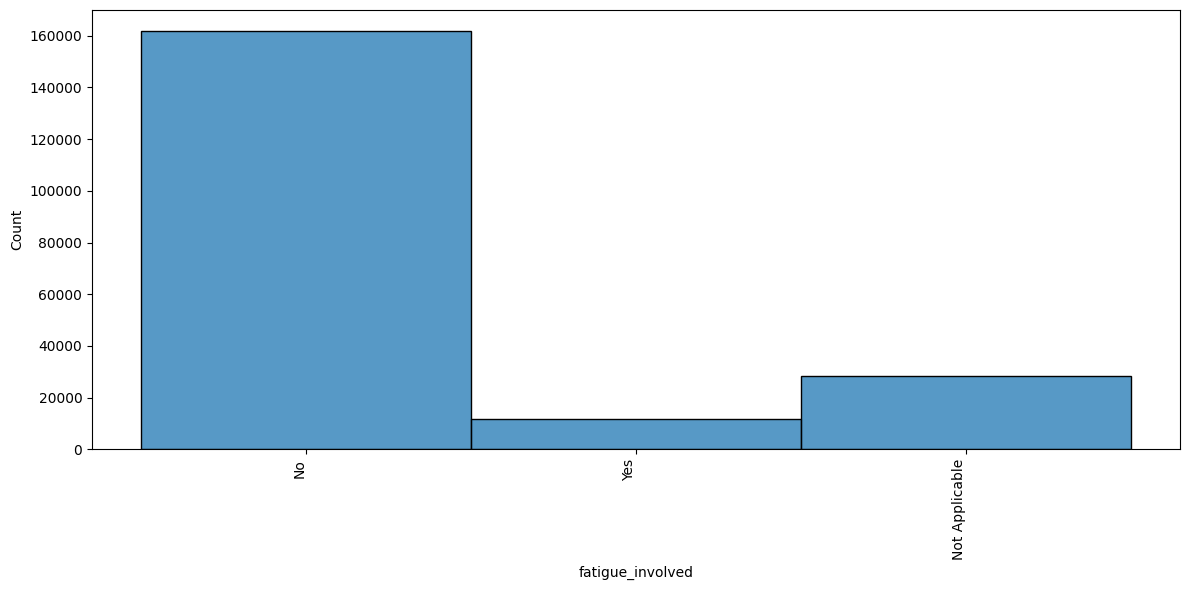

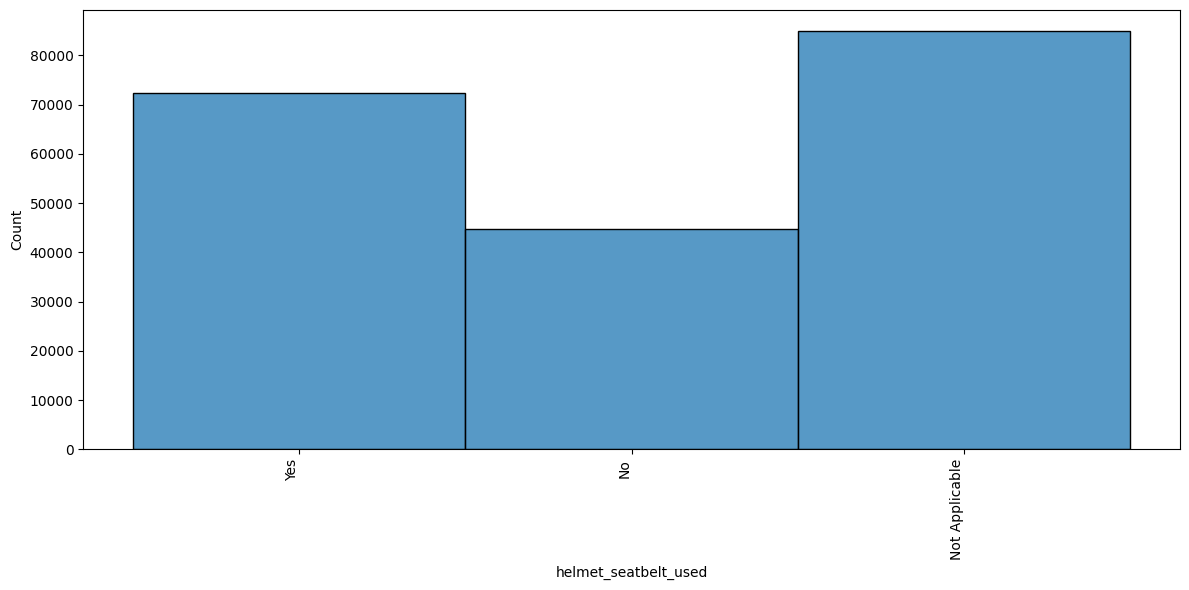

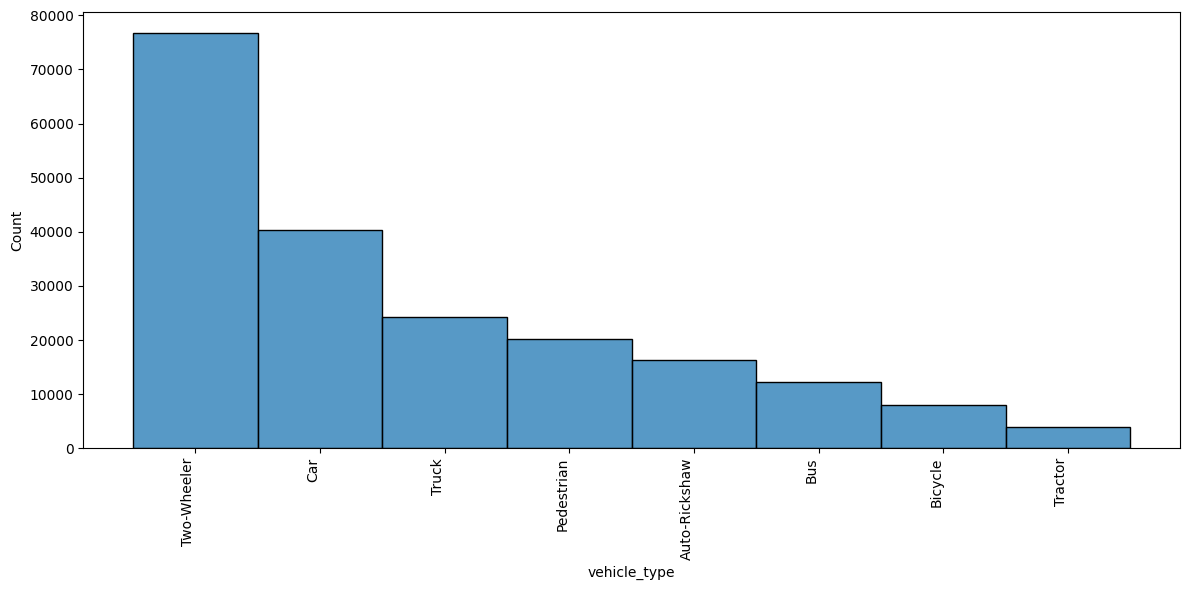

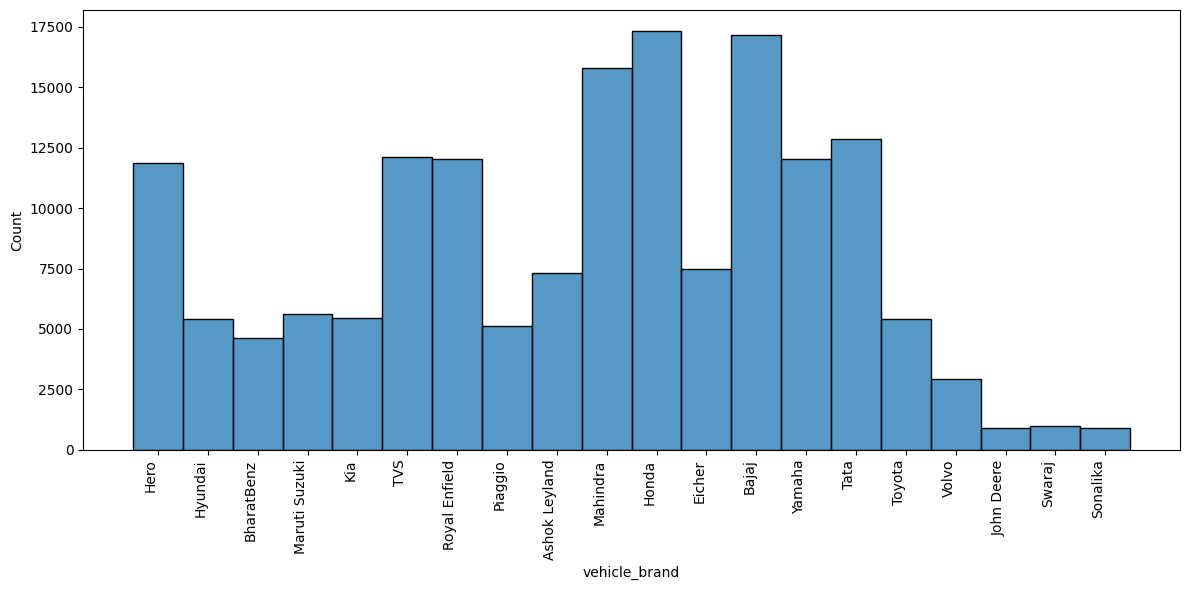

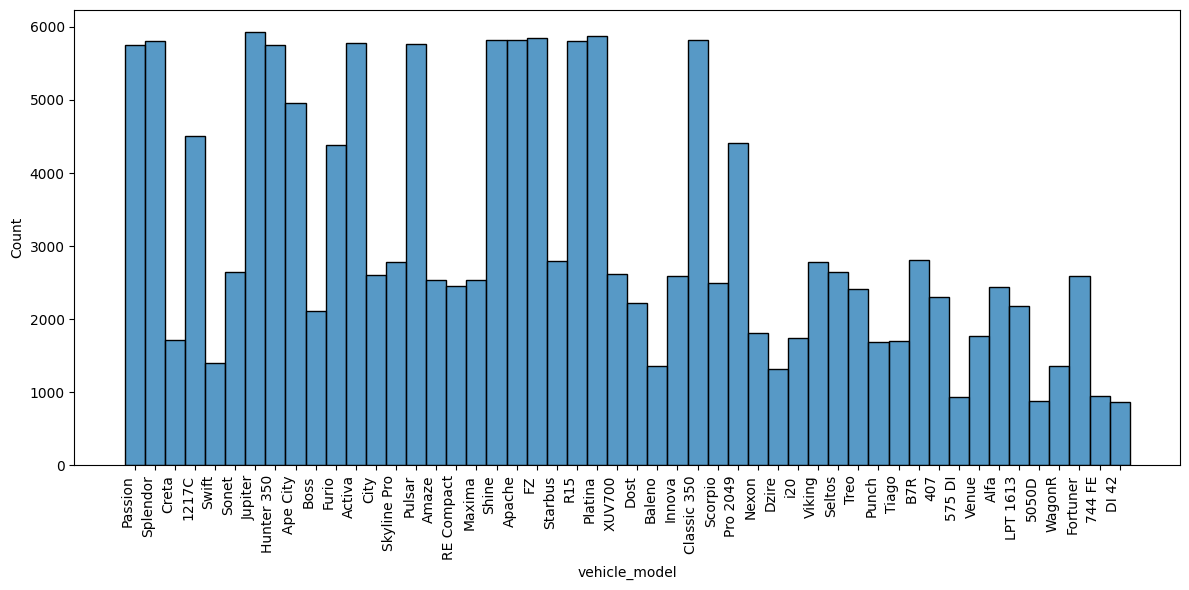

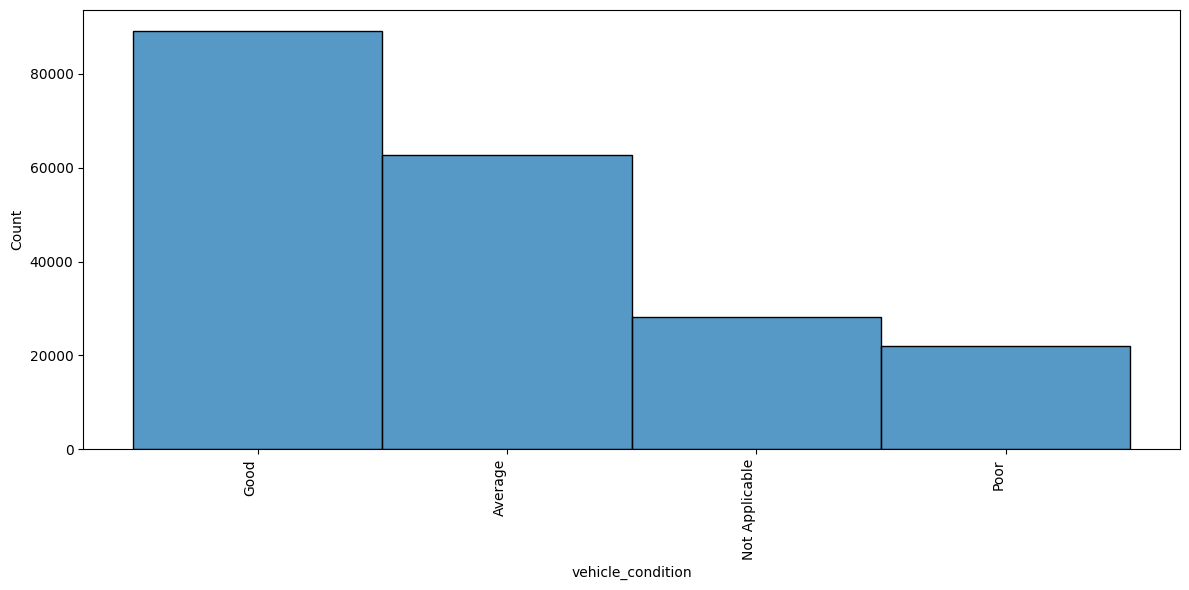

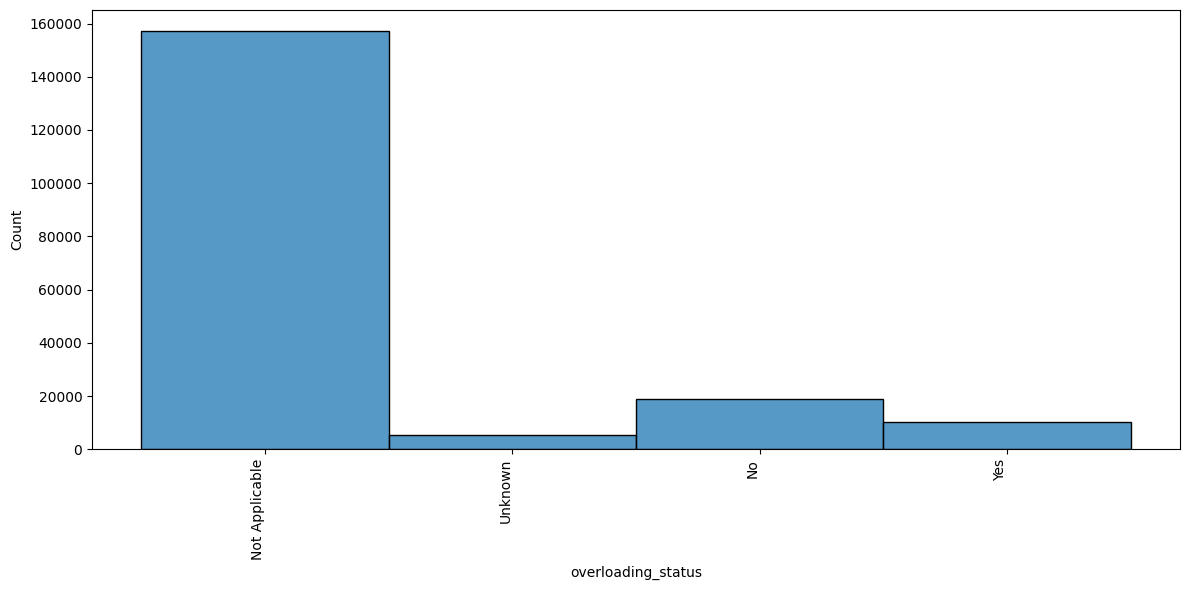

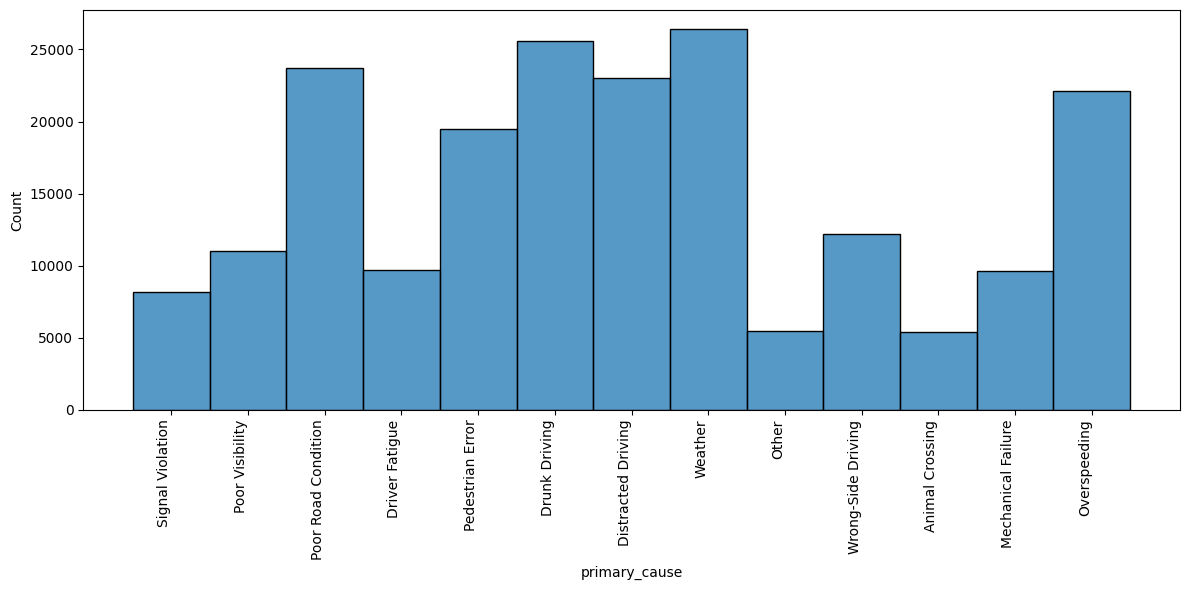

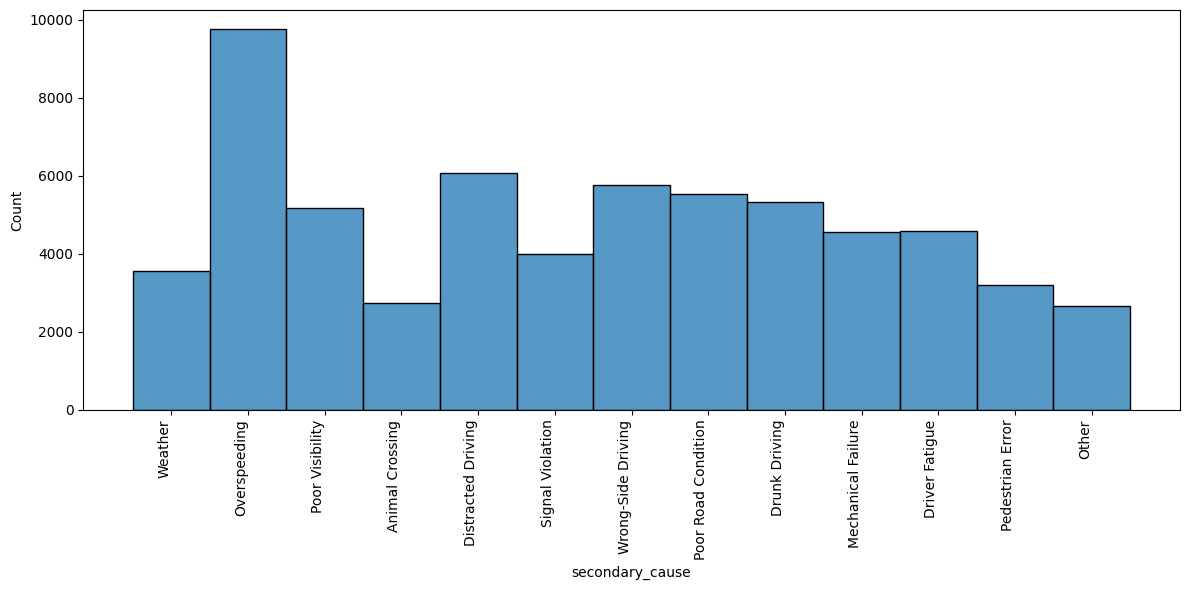

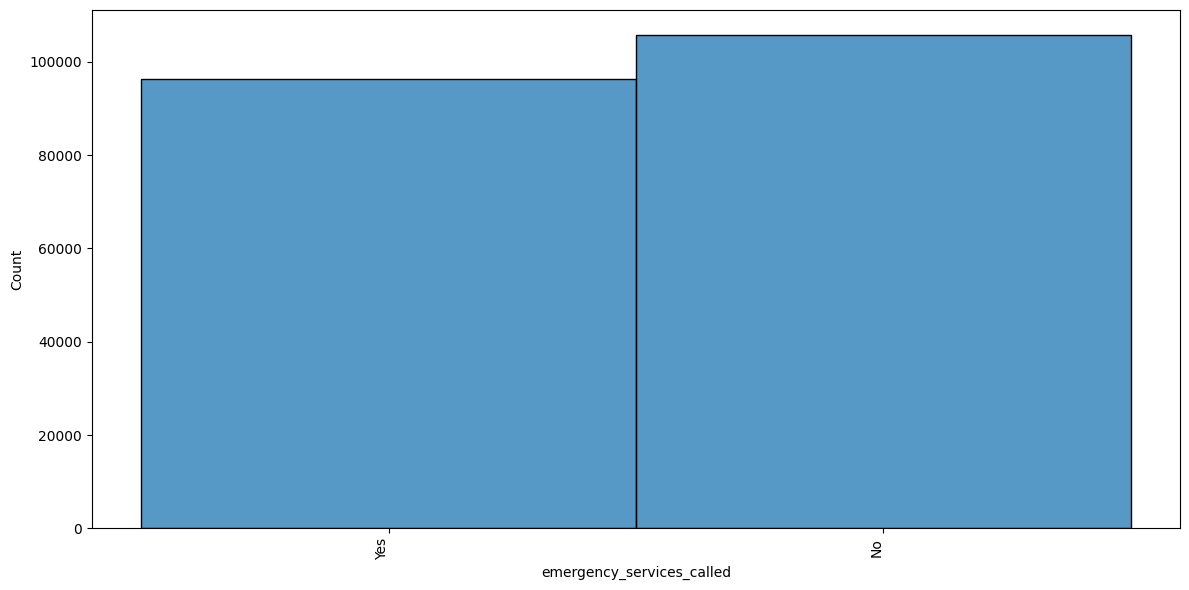

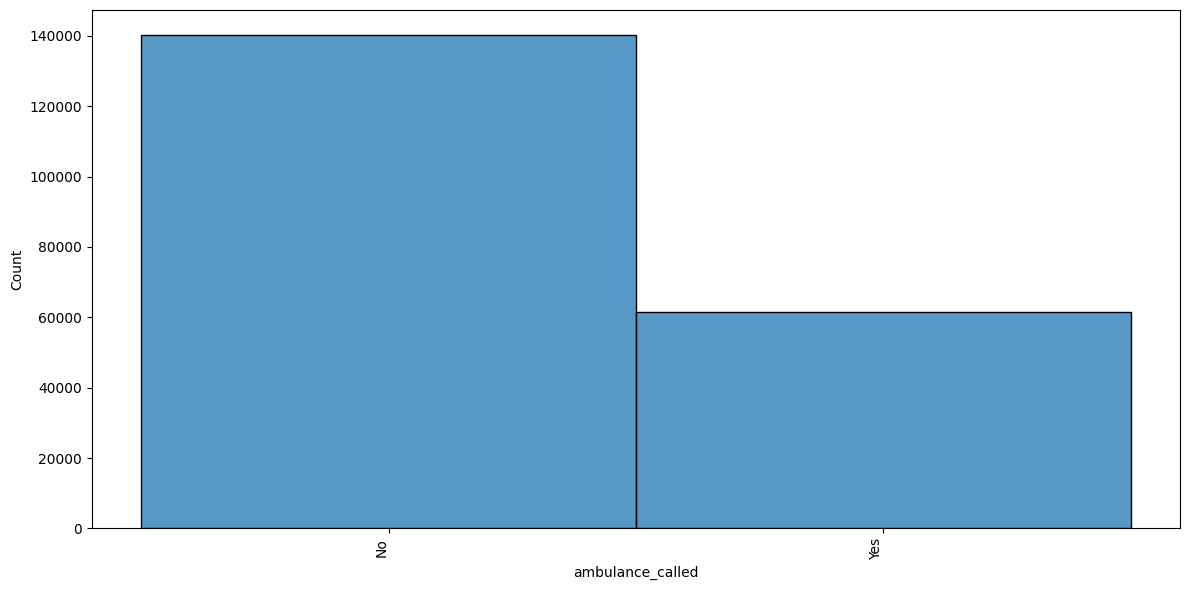

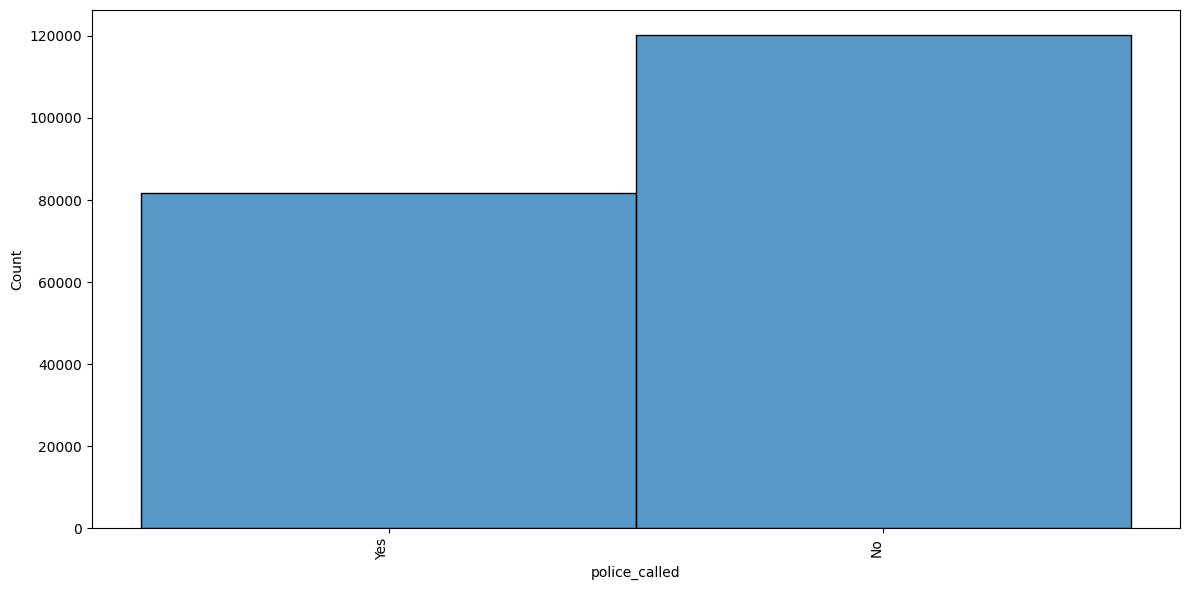

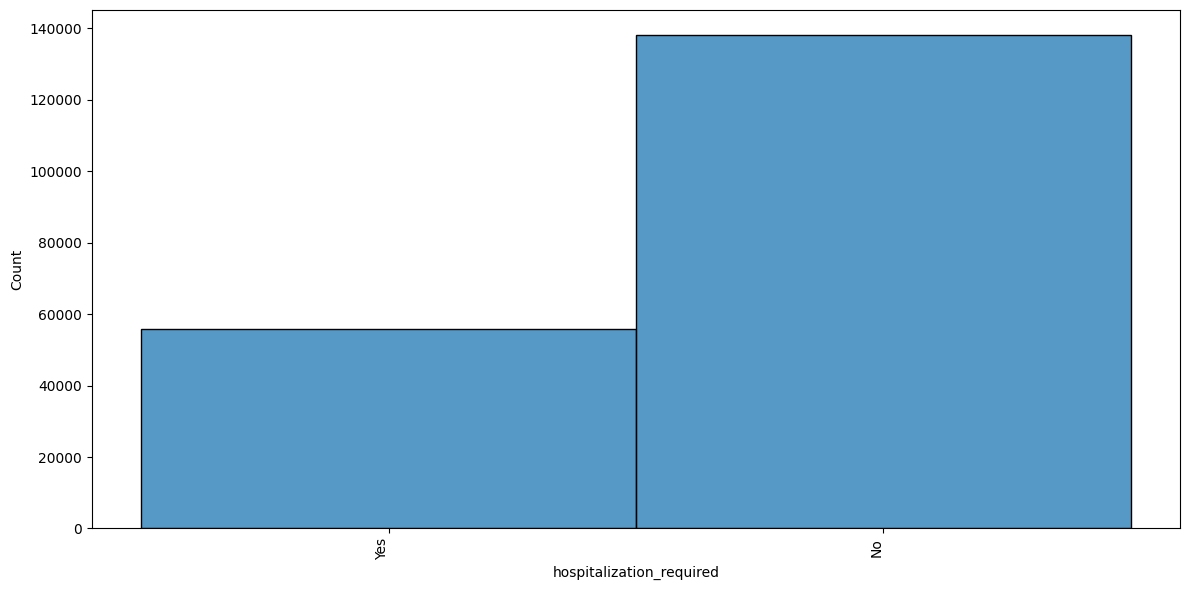

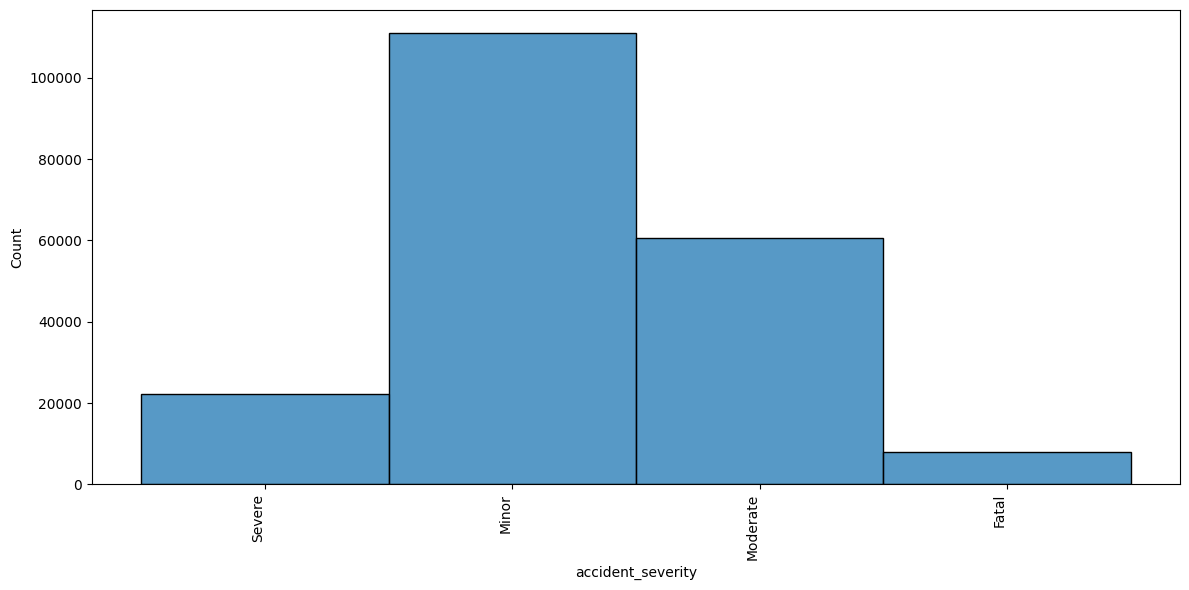

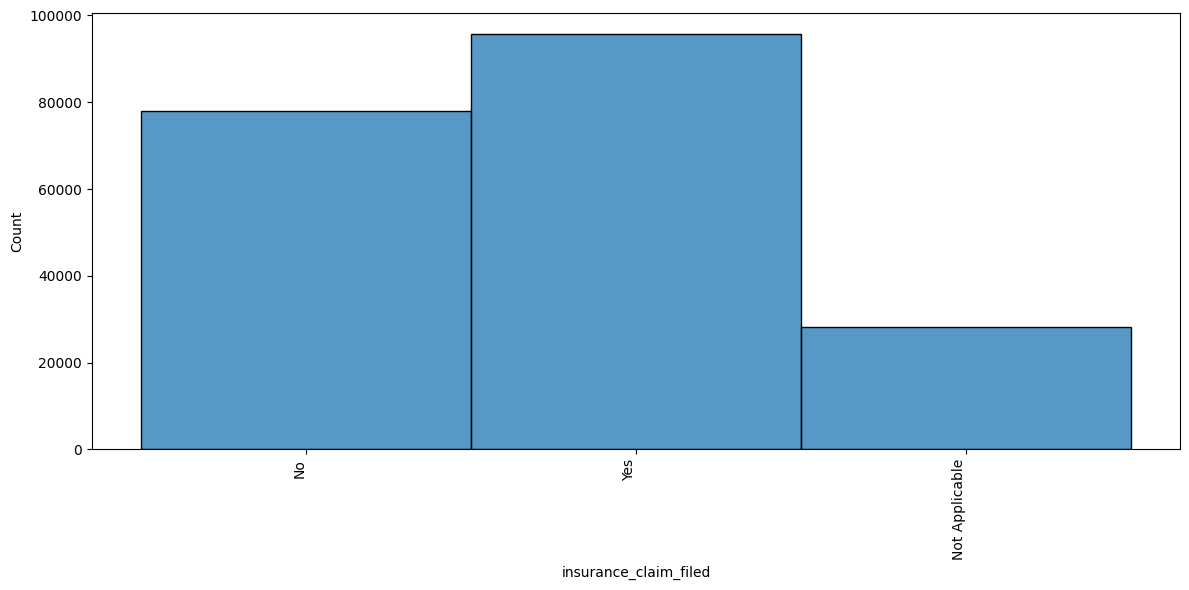

In [104]:
for i in non_num_cols:
    plt.figure(figsize=(12,6))
    sns.histplot(df[i])
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()


In [105]:
dt.isnull().sum()

0

In [106]:
(df['driving_experience_years']>df['driver_age']).sum()

276

there are 276 person whose driving experience uis greater thantheir age 

<Axes: xlabel='num_fatalities', ylabel='Count'>

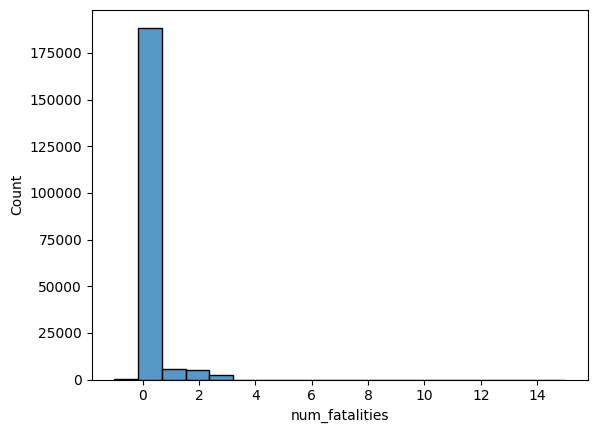

In [107]:
sns.histplot(df['num_fatalities'])

In [108]:
(df['num_fatalities'] < 0).sum()
# there are some (80)rows containing negative number of the fatalities
 

80

# Data Cleaning 


In [109]:
for i in ["traffic_signal_present","median_present","mobile_phone_used"]:
    print(df[i].value_counts())

traffic_signal_present
No       119324
Yes       64937
0          2126
N          2115
False      2099
Y          1135
True       1132
1          1069
Name: count, dtype: int64
median_present
No       110249
Yes       73944
0          1939
N          1906
False      1888
True       1345
1          1345
Y          1315
Name: count, dtype: int64
mobile_phone_used
No                143789
Not Applicable     28244
Yes                23005
False               2030
0                   1975
N                   1967
1                    355
Y                    334
True                 301
Name: count, dtype: int64


In [110]:
for i in ["traffic_signal_present","median_present","mobile_phone_used"]:
    df[i] = df[i].map({True:1,False:0,
                       "Yes":1,"No":0,
                       "Y":1,"N":0,
                    "Not Applicable":-1
                       })

here in have standardized the boolean type values to the 1 and 0
and not applicable values to the -1


In [111]:
for i in ["traffic_signal_present","median_present","mobile_phone_used"]:
    print(df[i].value_counts())

traffic_signal_present
0.0    121439
1.0     66072
Name: count, dtype: int64
median_present
0.0    112155
1.0     75259
Name: count, dtype: int64
mobile_phone_used
 0.0    145756
-1.0     28244
 1.0     23339
Name: count, dtype: int64


In [113]:
df.duplicated().sum()

980

In [114]:
df['accident_id'].duplicated().sum()

2000

In [115]:
df = df.drop_duplicates(subset='accident_id',keep='first')

In [118]:
df.shape

(200000, 48)

there were 2000 duplicated accident ids and rows 


In [119]:
df['weather_condition'] = df['weather_condition'].replace({'Rain': 'Rainy'})

In [122]:
for i in ['road_type','weather_condition']:
    df[i] = df[i].str.strip().str.title()
    

In [127]:
df['weather_condition'].nunique()

5

In [128]:
for c in ['road_type', 'weather_condition']:
    print(f'{c}: {df[c].nunique()} clean values : {df[c].dropna().unique().tolist()}')

road_type: 5 clean values : ['State Highway', 'Other District Road', 'National Highway', 'Village Road', 'Expressway']
weather_condition: 5 clean values : ['Clear', 'Rainy', 'Hazy', 'Foggy', 'Stormy']


In [135]:
len(df[df['driver_age']<20]['driver_age'])

18132

there are  18132 under age driver 


In [137]:
len(df[df['driver_age']>100]['driver_age'])

265

<Axes: xlabel='driver_age', ylabel='Count'>

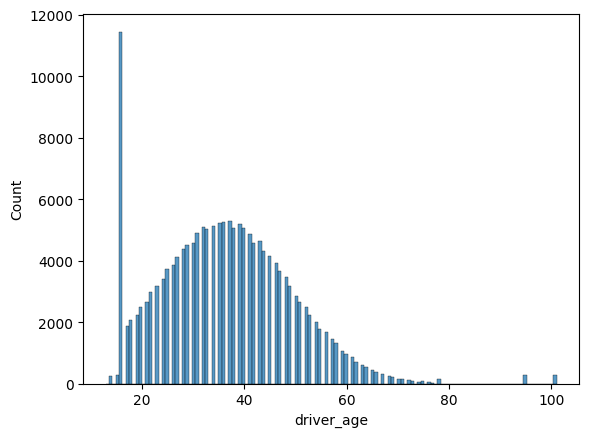

In [133]:
sns.histplot(df['driver_age'])

In [138]:
df.loc[df['driver_age']>100,'driver_age'] = np.nan

In [139]:
df.loc[df['num_fatalities'] < 0, 'num_fatalities'] = np.nan

# Null value imputation

In [157]:
df.columns

Index(['accident_id', 'accident_datetime', 'state', 'district', 'area_type',
       'latitude', 'longitude', 'road_type', 'road_condition', 'road_lighting',
       'number_of_lanes', 'speed_limit_kmph', 'estimated_speed_kmph',
       'junction_type', 'traffic_signal_present', 'median_present',
       'weather_condition', 'visibility_km', 'temperature_c', 'rainfall_mm',
       'driver_age', 'driver_gender', 'driving_experience_years',
       'license_status', 'alcohol_involved', 'distraction_involved',
       'mobile_phone_used', 'fatigue_involved', 'helmet_seatbelt_used',
       'vehicle_type', 'vehicle_age_years', 'vehicle_brand', 'vehicle_model',
       'vehicle_condition', 'overloading_status', 'primary_cause',
       'secondary_cause', 'emergency_services_called', 'ambulance_called',
       'police_called', 'response_time_minutes', 'hospitalization_required',
       'num_vehicles', 'num_injuries', 'num_fatalities', 'accident_severity',
       'insurance_claim_filed', 'insurance_cla

In [140]:
df['secondary_cause'] = df['secondary_cause'].fillna('None')

In [151]:
df['insurance_claim_amount'] = np.where(
    df['insurance_claim_filed'].isin(['No', 'Not Applicable']) & df['insurance_claim_amount'].isnull(),
    0, df['insurance_claim_amount'])

In [153]:
df['insurance_claim_amount']

0             0.0
1         26761.0
2          9295.0
3         48147.0
4         20636.0
           ...   
201995    90403.0
201996        NaN
201997    20274.0
201998    63623.0
201999        0.0
Name: insurance_claim_amount, Length: 200000, dtype: float64

In [154]:
df['insurance_claim_amount'] = df.groupby('state')['insurance_claim_amount'].transform(lambda s: s.fillna(s.median()))

In [155]:
df['insurance_claim_amount']

0             0.0
1         26761.0
2          9295.0
3         48147.0
4         20636.0
           ...   
201995    90403.0
201996        0.0
201997    20274.0
201998    63623.0
201999        0.0
Name: insurance_claim_amount, Length: 200000, dtype: float64

In [156]:
df['response_time_missing'] = df['response_time_minutes'].isnull().astype(int)
df['response_time_minutes'] = df.groupby('area_type')['response_time_minutes'].transform(lambda s: s.fillna(s.median()))

In [158]:
df['response_time_minutes']

0         86.178166
1         12.528603
2         12.223663
3         16.943981
4         12.223663
            ...    
201995    27.340183
201996    12.528603
201997    23.022140
201998     2.000000
201999    15.662700
Name: response_time_minutes, Length: 200000, dtype: float64

In [159]:
for c in ['vehicle_brand', 'vehicle_model']:
    df[c] = df[c].fillna('Not Applicable')


In [160]:
for c in ['driver_age', 'driving_experience_years', 'vehicle_age_years']:
    df[c] = df.groupby('vehicle_type')[c].transform(lambda s: s.fillna(s.median()))
    df[c] = df[c].fillna(df[c].median()) 

In [161]:
df[['driver_age', 'driving_experience_years', 'vehicle_age_years']]

,driver_age,driving_experience_years,vehicle_age_years
0,32.0,9.8,3.0
1,16.0,0.0,0.5
2,41.0,22.0,2.9
3,41.0,22.9,0.0
4,51.0,22.7,14.5
...,...,...,...
201995,44.0,18.5,4.0
201996,24.0,3.9,0.8
201997,30.0,11.4,0.4
201998,40.0,19.5,5.7


In [162]:
mode_cols = ['district', 'driver_gender', 'overloading_status', 'road_lighting', 'junction_type',
             'traffic_signal_present', 'median_present', 'weather_condition', 'hospitalization_required']
for c in mode_cols:
    df[c] = df[c].fillna(df[c].mode()[0])


In [165]:
df[mode_cols].isnull().sum()

district                    0
driver_gender               0
overloading_status          0
road_lighting               0
junction_type               0
traffic_signal_present      0
median_present              0
weather_condition           0
hospitalization_required    0
dtype: int64

In [ ]:
for c in ['number_of_lanes', 'speed_limit_kmph']:
    df[c] = df.groupby('road_type')[c].transform(lambda s: s.fillna(s.median()))

In [167]:
for c in ['visibility_km', 'temperature_c']:
    df[c] = df.groupby('weather_condition')[c].transform(lambda s: s.fillna(s.median()))

In [168]:
for c in ['latitude', 'longitude']:
    df[c] = df.groupby('state')[c].transform(lambda s: s.fillna(s.median()))

In [169]:
remaining_num = df.select_dtypes(include=[np.number]).columns
df[remaining_num] = df[remaining_num].apply(lambda s: s.fillna(s.median()))
remaining_cat = df.select_dtypes(include='object').columns
df[remaining_cat] = df[remaining_cat].apply(lambda s: s.fillna('Unknown'))

C:\Users\pushk\AppData\Local\Temp\ipykernel_11676\279761190.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat = df.select_dtypes(include='object').columns


In [171]:
df.isnull().sum().sum()

0